In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

daily_returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)

tickers = daily_returns.columns.tolist()
n_assets = len(tickers)

trading_days = 252
risk_free_rate = 0.02

daily_returns.head()

,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-01-05,-0.018060,-0.014676,-0.013369,0.015708,0.015077,0.005473,-0.023605
2015-01-06,-0.009419,-0.013415,-0.017300,0.018017,0.011399,0.009919,-0.011327
2015-01-07,0.012461,0.012897,0.012315,-0.001975,-0.005891,0.015331,0.011115
2015-01-08,0.017745,0.019149,0.016962,-0.013243,-0.004209,0.003775,0.013530
2015-01-09,-0.008014,-0.006586,-0.009603,0.010953,0.011385,0.000470,-0.004839


In [2]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio


def minimum_variance_weights(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def portfolio_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
    
    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x


def maximum_sharpe_weights(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def negative_sharpe(weights):
        return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]
    
    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x


def risk_contribution(weights, cov_matrix):
    portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal_contrib = np.dot(cov_matrix, weights)
    risk_contrib = weights * marginal_contrib / portfolio_var
    return risk_contrib


def risk_parity_weights(returns_window):
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def risk_parity_objective(weights):
        rc = risk_contribution(weights, cov_matrix)
        target_rc = np.array([1 / n_assets] * n_assets)
        return np.sum((rc - target_rc) ** 2)
    
    result = minimize(
        risk_parity_objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [3]:
def rolling_backtest(daily_returns, lookback_window=252, rebalance_window=21):
    strategy_returns = {
        "Equal Weight": [],
        "Minimum Variance": [],
        "Maximum Sharpe": [],
        "Risk Parity": [],
        "SPY Benchmark": []
    }
    
    dates = []
    
    for start in range(lookback_window, len(daily_returns) - rebalance_window, rebalance_window):
        train_window = daily_returns.iloc[start - lookback_window:start]
        test_window = daily_returns.iloc[start:start + rebalance_window]
        
        weights_dict = {
            "Equal Weight": np.array([1 / n_assets] * n_assets),
            "Minimum Variance": minimum_variance_weights(train_window),
            "Maximum Sharpe": maximum_sharpe_weights(train_window),
            "Risk Parity": risk_parity_weights(train_window)
        }
        
        for strategy, weights in weights_dict.items():
            returns = test_window.dot(weights)
            strategy_returns[strategy].extend(returns.tolist())
        
        strategy_returns["SPY Benchmark"].extend(test_window["SPY"].tolist())
        dates.extend(test_window.index.tolist())
    
    backtest_returns = pd.DataFrame(strategy_returns, index=dates)
    
    return backtest_returns

In [4]:
def performance_table(returns, risk_free_rate=0.02):
    table = pd.DataFrame({
        "Annualized Return": returns.mean() * trading_days,
        "Annualized Volatility": returns.std() * np.sqrt(trading_days),
        "Sharpe Ratio": (returns.mean() * trading_days - risk_free_rate) / (returns.std() * np.sqrt(trading_days))
    })
    
    return table.T

In [5]:
lookback_windows = [126, 252, 504]
rebalance_windows = [21, 63]

In [6]:
sensitivity_results = []

for lookback in lookback_windows:
    for rebalance in rebalance_windows:
        backtest_result = rolling_backtest(
            daily_returns,
            lookback_window=lookback,
            rebalance_window=rebalance
        )
        
        performance = performance_table(backtest_result, risk_free_rate)
        
        for strategy in performance.columns:
            sensitivity_results.append({
                "Lookback Window": lookback,
                "Rebalance Window": rebalance,
                "Strategy": strategy,
                "Annualized Return": performance.loc["Annualized Return", strategy],
                "Annualized Volatility": performance.loc["Annualized Volatility", strategy],
                "Sharpe Ratio": performance.loc["Sharpe Ratio", strategy]
            })

sensitivity_results = pd.DataFrame(sensitivity_results)

sensitivity_results.head()

,Lookback Window,Rebalance Window,Strategy,Annualized Return,Annualized Volatility,Sharpe Ratio
0,126,21,Equal Weight,0.089826,0.134203,0.520301
1,126,21,Minimum Variance,0.062919,0.097669,0.439433
2,126,21,Maximum Sharpe,0.091866,0.152181,0.472244
3,126,21,Risk Parity,0.084172,0.113680,0.564496
4,126,21,SPY Benchmark,0.131869,0.181260,0.617174


In [7]:
sensitivity_results.to_csv("../data/processed/parameter_sensitivity_results.csv", index=False)

In [8]:
sharpe_pivot = sensitivity_results.pivot_table(
    index=["Lookback Window", "Rebalance Window"],
    columns="Strategy",
    values="Sharpe Ratio"
)

sharpe_pivot

Strategy                          Equal Weight  Maximum Sharpe  \
Lookback Window Rebalance Window                                 
126             21                    0.520301        0.472244   
                63                    0.500527        0.554117   
252             21                    0.570779        0.467649   
                63                    0.550836        0.516718   
504             21                    0.563588        0.783376   
                63                    0.541899        0.631783   

Strategy                          Minimum Variance  Risk Parity  SPY Benchmark  
Lookback Window Rebalance Window                                                
126             21                        0.439433     0.564496       0.617174  
                63                        0.385714     0.531376       0.597985  
252             21                        0.519069     0.646951       0.665409  
                63                        0.512096     0.622418       0.645816  
504             21                        0.570114     0.631838       0.659134  
                63                        0.553687     0.673751       0.637886

In [9]:
sharpe_pivot.to_csv("../data/processed/parameter_sensitivity_sharpe.csv")

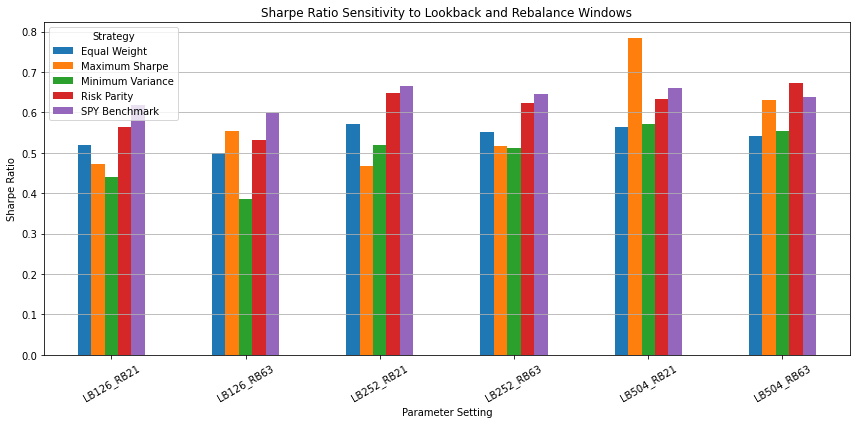

In [10]:
plot_data = sharpe_pivot.reset_index()
plot_data["Parameter Setting"] = (
    "LB" + plot_data["Lookback Window"].astype(str) +
    "_RB" + plot_data["Rebalance Window"].astype(str)
)

plot_data = plot_data.set_index("Parameter Setting")
plot_data = plot_data.drop(columns=["Lookback Window", "Rebalance Window"])

plot_data.plot(kind="bar", figsize=(12, 6))

plt.title("Sharpe Ratio Sensitivity to Lookback and Rebalance Windows")
plt.xlabel("Parameter Setting")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("../figures/parameter_sensitivity_sharpe.png", dpi=300)
plt.show()

In [11]:
strategy_stability = sensitivity_results.groupby("Strategy")["Sharpe Ratio"].agg(
    Mean_Sharpe="mean",
    Std_Sharpe="std",
    Min_Sharpe="min",
    Max_Sharpe="max"
).sort_values("Mean_Sharpe", ascending=False)

strategy_stability

,Mean_Sharpe,Std_Sharpe,Min_Sharpe,Max_Sharpe
Strategy,,,,
SPY Benchmark,0.637234,0.025653,0.597985,0.665409
Risk Parity,0.611805,0.053467,0.531376,0.673751
Maximum Sharpe,0.570981,0.120386,0.467649,0.783376
Equal Weight,0.541322,0.026685,0.500527,0.570779
Minimum Variance,0.496686,0.070671,0.385714,0.570114


In [12]:
strategy_stability.to_csv("../data/processed/parameter_sensitivity_stability.csv")

## Parameter Sensitivity Interpretation

This parameter sensitivity analysis evaluates whether strategy performance is robust to different lookback windows and rebalancing frequencies. The analysis compares 126-day, 252-day, and 504-day estimation windows, combined with 21-day and 63-day rebalancing windows.

The results show that the SPY benchmark has the highest average Sharpe ratio and the lowest variability across parameter settings. Among the optimized strategies, the risk parity portfolio is the most robust, with a relatively high mean Sharpe ratio and moderate sensitivity to parameter choices.

The maximum Sharpe strategy shows the highest parameter sensitivity. Although it achieves the highest Sharpe ratio under the 504-day lookback and 21-day rebalancing setting, its performance varies substantially across parameter choices. This suggests that maximum Sharpe optimization is more vulnerable to estimation error and parameter dependence.

Overall, the sensitivity analysis supports the earlier finding that risk parity provides a more stable risk-adjusted performance profile among the optimized strategies, while maximum Sharpe optimization may be less reliable out of sample.